In [17]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_gpus = 1 if device=='cuda' else 0
print(device)

cuda


In [18]:
import numpy as np
from pathlib import Path

base = Path("RDP_exp_data/mnist_lr_eps_8.0_a_2.0_dataset_100")

losses_in  = np.load(base / "losses_in.npy")     # shape depends on how you saved it
losses_out = np.load(base / "losses_out.npy")

print("losses_in:", losses_in.shape, losses_in.dtype)
print("losses_out:", losses_out.shape, losses_out.dtype)
print(losses_in)
print(losses_out)


losses_in: (50000,) float32
losses_out: (50000,) float32
[-4.07696   -4.160248  -4.5075445 ... -3.74652   -4.2203007 -3.8784308]
[-4.435562  -4.7048306 -4.41618   ... -5.167106  -6.318206  -4.942835 ]


In [19]:
class LoadDataset(torch.utils.data.Dataset):
    def __init__(self, N, x, y, x_dim, z_dim):
        self.x = x
        self.y = y
        # file imports and object initialization
        
        self.N = N
        self.x_dim = x_dim
        self.z_dim = z_dim

    def __getitem__(self, ix):
        a, b = self.x[ix,0:self.x_dim], self.y[ix,0:self.z_dim]
        
        return a, b
    
    def __len__(self):
        return self.N

In [21]:
%reload_ext autoreload
from renyi import RenyiDivergenceEstimator
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import TQDMProgressBar

x_dim = 1 #plaintext length of a single sample
z_dim = 1 #ciphertext length of a single sample
N = 49999 # num samples -1
lr = 1e-4 #learning rate
epochs = 300 #epochs
batch_size = 5000 #batch size
Renyi_order = 2
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
devices = 1  # one device either way

from pytorch_lightning.loggers import CSVLogger

csv_logger = CSVLogger("lightning_logs", name="renyi_run")

#format data
loss_type = ['mine']
# X, Y already constructed as tensors of shape (N, 1)
X = torch.tensor(losses_in,  dtype=torch.float32).view(-1, 1)
Y = torch.tensor(losses_out, dtype=torch.float32).view(-1, 1)
N = min(len(X), len(Y))
X, Y = X[:N], Y[:N]  # ensure same length

# --- 80/20 split: first 80% train, last 20% test ---
n_train = int(0.8 * N)
X_train, Y_train = X[:n_train], Y[:n_train]
X_test,  Y_test  = X[n_train:], Y[n_train:]

train_loader = torch.utils.data.DataLoader(
    LoadDataset(len(X_train), X_train, Y_train, x_dim=1, z_dim=1),
    batch_size=batch_size,
    shuffle=True,      # ok to shuffle *within* the training set
    drop_last=False
)

test_loader = torch.utils.data.DataLoader(
    LoadDataset(len(X_test), X_test, Y_test, x_dim=1, z_dim=1),
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)



trainer = Trainer(
    max_epochs=epochs,
    accelerator=accelerator,
    devices=devices,
    logger=csv_logger,
    enable_checkpointing=False,
    enable_progress_bar=True,
    callbacks=[TQDMProgressBar(refresh_rate=10)],
    log_every_n_steps=10,
)
model = RenyiDivergenceEstimator(
    lr=lr,
    renyi_order=Renyi_order,
    ema_rate=0.25,   # your EMA rate (beta)
    hidden=100,
)


trainer.fit(model, train_dataloaders=train_loader)
results = trainer.test(model, dataloaders=test_loader)

print("DV-Rényi lower bound (epoch-avg):", results[0]["test_renyi_lb"])
print("Same value from model:", model.avg_test_renyi_lb)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ T           │ T     │ 10.4 K │ train │     0 │
│ 1 │ energy_loss │ Renyi │ 10.4 K │ train │     0 │
└───┴─────────────┴───────┴────────┴───────┴───────┘

Trainable params: 10.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 299: 100%|██████████| 8/8 [00:00<00:00, 13.44it/s, v_num=11, train_loss_step=-3.60, train_renyi_lb_step=3.600, train_loss_epoch=-4.99, train_renyi_lb_epoch=4.990]    

...

Epoch 299: 100%|██████████| 8/8 [00:00<00:00, 13.40it/s, v_num=11, train_loss_step=-3.60, train_renyi_lb_step=3.600, train_loss_epoch=-4.99, train_renyi_lb_epoch=4.990]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 40.96it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    -5.553105354309082     │
│       test_renyi_lb       │     5.553105354309082     │
└───────────────────────────┴───────────────────────────┘

DV-Rényi lower bound (epoch-avg): 5.553105354309082
Same value from model: 5.553105354309082


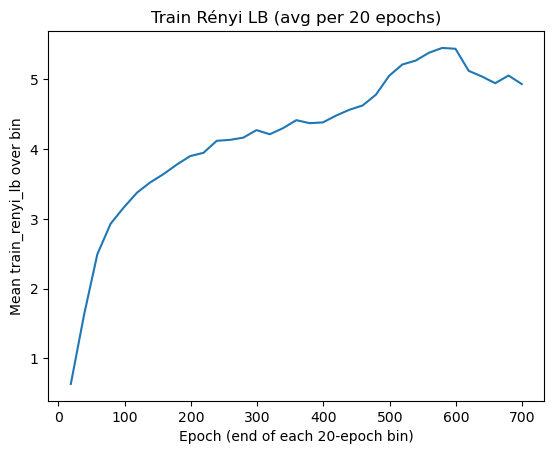

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
df = pd.read_csv(metrics_path)

# Lightning writes multiple rows; keep only rows where the epoch-aggregated metric exists
# (column name is typically train_renyi_lb_epoch because you logged on_epoch=True)
epoch_df = df[["epoch", "train_renyi_lb_epoch"]].dropna()

# If there are multiple rows per epoch, keep the last one per epoch
epoch_df = epoch_df.groupby("epoch", as_index=False).last()

# Bin epochs into groups of 20 and average within each bin
epoch_df["bin"] = (epoch_df["epoch"] // 20).astype(int)
avg20 = epoch_df.groupby("bin", as_index=False)["train_renyi_lb_epoch"].mean()
avg20["epoch_end"] = avg20["bin"] * 20 + 19  # label each point by the ending epoch in the bin

plt.figure()
plt.plot(avg20["epoch_end"], avg20["train_renyi_lb_epoch"])
plt.xlabel("Epoch (end of each 20-epoch bin)")
plt.ylabel("Mean train_renyi_lb over bin")
plt.title("Train Rényi LB (avg per 20 epochs)")
plt.show()


In [16]:
import numpy as np
import math

Renyi_order = 2.0
# -------------------------
# Utilities
# -------------------------
def _to_1d_finite(x):
    x = np.asarray(x).reshape(-1).astype(np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("No finite samples after filtering NaN/Inf.")
    return x

def logmeanexp(a):
    a = np.asarray(a, dtype=np.float64)
    m = np.max(a)
    return m + np.log(np.mean(np.exp(a - m)))

# -------------------------
# Gaussian MLE fit + logpdf
# -------------------------
def fit_gaussian_mle(x, var_floor=1e-12):
    x = _to_1d_finite(x)
    mu = float(np.mean(x))
    var = float(np.mean((x - mu) ** 2))  # MLE (divide by n)
    var = max(var, var_floor)
    return mu, var

def logpdf_gaussian(x, mu, var):
    x = np.asarray(x, dtype=np.float64)
    return -0.5 * (np.log(2.0 * np.pi * var) + (x - mu) ** 2 / var)

# -------------------------
# Rényi divergence estimators
#   D_alpha(Q||P) = 1/(alpha-1) * log ∫ q(x)^alpha p(x)^(1-alpha) dx
# -------------------------
def renyi_gaussian_closed_form(mu_q, var_q, mu_p, var_p, alpha):
    """
    Closed-form for 1D Gaussian q=N(mu_q,var_q), p=N(mu_p,var_p).
    Returns +inf if the integral diverges (can happen for alpha>1 if p is too "narrow").
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    # Derived by completing the square in the exponent:
    # A = a/var_q - (a-1)/var_p must be > 0 for finiteness.
    A = a / var_q - (a - 1.0) / var_p
    if A <= 0:
        return float("inf")

    B = a * mu_q / var_q - (a - 1.0) * mu_p / var_p
    C = a * (mu_q ** 2) / var_q - (a - 1.0) * (mu_p ** 2) / var_p

    # log I where I = ∫ q^a p^(1-a)
    logI = (
        -0.5 * a * np.log(var_q)
        -0.5 * (1.0 - a) * np.log(var_p)
        -0.5 * np.log(A)
        -0.5 * (C - (B * B) / A)
    )
    return float(logI / (a - 1.0))

def renyi_gaussian_mle_closed(q_samples, p_samples, alpha):
    mu_q, var_q = fit_gaussian_mle(q_samples)
    mu_p, var_p = fit_gaussian_mle(p_samples)
    D = renyi_gaussian_closed_form(mu_q, var_q, mu_p, var_p, alpha)
    return D, (mu_q, var_q, mu_p, var_p)

def renyi_gaussian_mle_mc(q_samples, p_samples, alpha):
    """
    MLE-fit Gaussians to Q and P, then estimate:
      D_alpha(Q||P) = (1/(a-1)) log E_{X~P}[ (q(X)/p(X))^a ]
    using X as your *empirical* p_samples (MC under P).
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    q = _to_1d_finite(q_samples)
    p = _to_1d_finite(p_samples)

    mu_q, var_q = fit_gaussian_mle(q)
    mu_p, var_p = fit_gaussian_mle(p)

    log_q = logpdf_gaussian(p, mu_q, var_q)
    log_p = logpdf_gaussian(p, mu_p, var_p)

    # log w_i = a*(log q(x_i) - log p(x_i))
    logw = a * (log_q - log_p)
    logE = logmeanexp(logw)  # log E_P[(q/p)^a]
    return float(logE / (a - 1.0)), (mu_q, var_q, mu_p, var_p)

# -------------------------
# Optional: GMM MLE + MC (if sklearn is available)
# -------------------------
def renyi_gmm_mle_mc(q_samples, p_samples, alpha, n_components=3, reg_covar=1e-6, seed=0):
    """
    Fits separate 1D GMMs to Q and P by EM (sklearn), then uses empirical P samples for MC:
      D_alpha(Q||P) = (1/(a-1)) log E_{X~P}[ (q_hat(X)/p_hat(X))^a ].
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    q = _to_1d_finite(q_samples).reshape(-1, 1)
    p = _to_1d_finite(p_samples).reshape(-1, 1)

    try:
        from sklearn.mixture import GaussianMixture
    except Exception as e:
        raise ImportError("scikit-learn not available; install or skip GMM.") from e

    gq = GaussianMixture(n_components=n_components, reg_covar=reg_covar, random_state=seed)
    gp = GaussianMixture(n_components=n_components, reg_covar=reg_covar, random_state=seed)
    gq.fit(q)
    gp.fit(p)

    # score_samples gives log density
    log_q = gq.score_samples(p)
    log_p = gp.score_samples(p)

    logw = a * (log_q - log_p)
    logE = logmeanexp(logw)
    return float(logE / (a - 1.0))

# -------------------------
# Optional: bootstrap CI (rough)
# -------------------------
def bootstrap_ci(estimator_fn, q_samples, p_samples, alpha, B=200, seed=0):
    q = _to_1d_finite(q_samples)
    p = _to_1d_finite(p_samples)
    rng = np.random.default_rng(seed)

    n_q, n_p = len(q), len(p)
    ests = np.empty(B, dtype=np.float64)
    for b in range(B):
        qb = q[rng.integers(0, n_q, size=n_q)]
        pb = p[rng.integers(0, n_p, size=n_p)]
        ests[b] = estimator_fn(qb, pb, alpha)[0] if isinstance(estimator_fn(qb, pb, alpha), tuple) else estimator_fn(qb, pb, alpha)

    est = float(np.mean(ests))
    lo, hi = np.quantile(ests, [0.025, 0.975])
    return est, (float(lo), float(hi))

# -------------------------
# Run on your arrays
# -------------------------
alpha = float(Renyi_order)  # e.g., 2.0

Q = losses_in   # treat as Q samples
P = losses_out  # treat as P samples

D_gauss_closed, params = renyi_gaussian_mle_closed(Q, P, alpha)
D_gauss_mc,     params2 = renyi_gaussian_mle_mc(Q, P, alpha)

print("\n=== Gaussian MLE results ===")
print("params (mu_q, var_q, mu_p, var_p):", params)
print(f"D_{alpha}(Q||P) Gaussian closed-form  : {D_gauss_closed:.6f}")
print(f"D_{alpha}(Q||P) Gaussian MLE + MC      : {D_gauss_mc:.6f}")

# Optional: GMM
try:
    D_gmm_mc = renyi_gmm_mle_mc(Q, P, alpha, n_components=3)
    print("\n=== GMM(3) MLE + MC ===")
    print(f"D_{alpha}(Q||P) GMM(3) MLE + MC        : {D_gmm_mc:.6f}")
except ImportError as e:
    print("\n(skipping GMM; scikit-learn not available)")

# Optional: bootstrap CI (on Gaussian closed-form plug-in)
est_mean, (ci_lo, ci_hi) = bootstrap_ci(renyi_gaussian_mle_closed, Q, P, alpha, B=200, seed=0)
print("\n=== Rough bootstrap (Gaussian plug-in) ===")
print(f"bootstrap mean: {est_mean:.6f}  95% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")



alpha = float(Renyi_order)  # e.g., 2.0

Q = losses_out   # treat as Q samples
P = losses_in  # treat as P samples

D_gauss_closed, params = renyi_gaussian_mle_closed(Q, P, alpha)
D_gauss_mc,     params2 = renyi_gaussian_mle_mc(Q, P, alpha)

print("\n=== Gaussian MLE results ===")
print("params (mu_q, var_q, mu_p, var_p):", params)
print(f"D_{alpha}(P||Q) Gaussian closed-form  : {D_gauss_closed:.6f}")
print(f"D_{alpha}(P||Q) Gaussian MLE + MC      : {D_gauss_mc:.6f}")

# Optional: GMM
try:
    D_gmm_mc = renyi_gmm_mle_mc(Q, P, alpha, n_components=3)
    print("\n=== GMM(3) MLE + MC ===")
    print(f"D_{alpha}(P||Q) GMM(3) MLE + MC        : {D_gmm_mc:.6f}")
except ImportError as e:
    print("\n(skipping GMM; scikit-learn not available)")

# Optional: bootstrap CI (on Gaussian closed-form plug-in)
est_mean, (ci_lo, ci_hi) = bootstrap_ci(renyi_gaussian_mle_closed, Q, P, alpha, B=200, seed=0)
print("\n=== Rough bootstrap (Gaussian plug-in) ===")
print(f"bootstrap mean: {est_mean:.6f}  95% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")


=== Gaussian MLE results ===
params (mu_q, var_q, mu_p, var_p): (-3.7822916554880144, 0.20745735940376347, -4.991584556355477, 0.21869609678988391)
D_2.0(Q||P) Gaussian closed-form  : 6.361339
D_2.0(Q||P) Gaussian MLE + MC      : 5.604859

=== GMM(3) MLE + MC ===
D_2.0(Q||P) GMM(3) MLE + MC        : 11.944342

=== Rough bootstrap (Gaussian plug-in) ===
bootstrap mean: 6.363595  95% CI: [6.188413, 6.518249]

=== Gaussian MLE results ===
params (mu_q, var_q, mu_p, var_p): (-4.991584556355477, 0.21869609678988391, -3.7822916554880144, 0.20745735940376347)
D_2.0(P||Q) Gaussian closed-form  : 7.454326
D_2.0(P||Q) Gaussian MLE + MC      : 7.606316

=== GMM(3) MLE + MC ===
D_2.0(P||Q) GMM(3) MLE + MC        : 15.723728

=== Rough bootstrap (Gaussian plug-in) ===
bootstrap mean: 7.464246  95% CI: [7.227671, 7.695237]
